In [ ]:
import config_paths_ipynb

import warnings

import pandas as pd
from IPython.display import Markdown, display

from ibd_biom_glycoda.config import DATASETS_DIR, FIGURE_DIR
from ibd_biom_glycoda.utils import seed_everything
from ibd_biom_glycoda.data.dataset import (
    generate_demographic_comparison,
    load_dataset_excel,
    prepare_ibd_dataset,
)
from ibd_biom_glycoda.analysis.similarity import (
    compare_similarity_geometries,
    prepare_similarity_representations,
    run_global_similarity_inference,
)
from ibd_biom_glycoda.plotting.similarity import plot_cohort_ordination_grid
from ibd_biom_glycoda.plotting.style import (
    generate_semantic_colors,
    rcparams_aga,
    save_figure_aga_compliant,
)

warnings.filterwarnings("ignore")

SEED = 42
seed_everything(SEED)

PALETTE = "okabe_ito"
rcparams_aga(palette=PALETTE)
DISEASE_COLORS = generate_semantic_colors(
    palette=PALETTE,
    preview=False,
)[0]


Notebook config loaded. Project root added: C:\Users\konst\GitProjects\ibd-biom-glycoda


# Does disease shape the overall IgG glycome?

Glycan peaks share a fixed total, so the distance between two samples depends on the geometry we choose. We use deterministic CLR coordinates and Aitchison distance as the primary representation, then ask whether the visual separation is supported by adjusted multivariate inference.

## Import and prepare data


In [ ]:
# Import data
fname = "ibd_biom_prospective_dataset_baseline.xlsx"
df_ibd = load_dataset_excel(fname, data_dir=DATASETS_DIR)

# Prepare multi-class dataset
df_multi, coda_cols = prepare_ibd_dataset(df_ibd, binary=False)
print(f"\nValue counts for multi-class dataset:\n{df_multi['DISEASE'].value_counts()}")

print(f"Loaded dataset shape: {df_ibd.shape}")
print(f"Prepared dataset shape: {df_multi.shape}")

# Prepare binary dataset
df_binary = df_multi.copy()
df_binary["DISEASE"] = df_binary["DISEASE"].replace(
    {"HC": "Non-IBD", "SC": "Non-IBD", "CD": "IBD", "UC": "IBD"}
)
print(f"\nValue counts for binary dataset:\n{df_binary['DISEASE'].value_counts()}")


Dropped 0 low abundant GP columns: []
Retained 24 GP columns: ['GP1_FA1', 'GP2_A2', 'GP3_A2B', 'GP4_FA2', 'GP5_M5', 'GP6_FA2B', 'GP7_A2G1', 'GP8_FA2_6_G1', 'GP9_FA2_3_G1', 'GP10_FA2_6_BG1', 'GP11_FA2_3_BG1', 'GP12_A2G2', 'GP13_A2BG2', 'GP14_FA2G2', 'GP15_FA2BG2', 'GP16_FA2G1S1', 'GP17_A2G2S1', 'GP18_FA2G2S1', 'GP19_FA2BG2S1', 'GP20__', 'GP21_A2G2S2', 'GP22_A2BG2S2', 'GP23_FA2G2S2', 'GP24_FA2BG2S2']

Value counts for multi-class dataset:
DISEASE
HC    375
CD    362
SC    356
UC    274
Name: count, dtype: int64
Loaded dataset shape: (1449, 31)
Prepared dataset shape: (1367, 31)

Value counts for binary dataset:
DISEASE
Non-IBD    731
IBD        636
Name: count, dtype: int64


In [ ]:
COVARIATES = ["Age", "Sex"]
PERMANOVA_COVARIATES = ["Age", "Sex", "Cohort"]
N_PERMUTATIONS = 999

DISEASE_ORDER_MULTI = ["HC", "SC", "CD", "UC"]
DISEASE_ORDER_BINARY = ["Non-IBD", "IBD"]
COHORT_ORDER = ["UK", "US", "IT", "NL"]


In [ ]:
# Validate and prepare the two prespecified endpoint representations
binary_similarity = prepare_similarity_representations(
    df_binary,
    coda_cols,
    residualization_covariates=COVARIATES,
    random_state=SEED,
)
multiclass_similarity = prepare_similarity_representations(
    df_multi,
    coda_cols,
    residualization_covariates=COVARIATES,
    random_state=SEED,
)

display(multiclass_similarity.contract_summary)


,Check,Value
0,Analyzed samples,1.367000e+03
1,Analyzed glycan peaks,2.400000e+01
2,Minimum peak percentage,2.455978e-02
3,Maximum absolute closure error,9.947598e-14
4,Maximum absolute CLR row sum,7.771561e-15


# Dataset description

In [ ]:
generate_demographic_comparison(
    df=df_multi,
    by_disease=False,
    binary=False,
    disease_order=DISEASE_ORDER_MULTI,
    cohort_order=COHORT_ORDER,
    alpha=0.05,
    show_pvalues=False,
)


Group,UK,US,IT,NL
n,406,472,307,182
"Age (median, IQR)",33.5 (26.0-48.5),38.0 (30.0-52.0),54.0 (38.0-64.0),47.0 (26.0-61.0)
"Females (n, %)",194 (47.8%),291 (61.7%),149 (48.5%),106 (58.2%)
"Group - HC (n, %)",88 (21.7%),36 (7.6%),187 (60.9%),64 (35.2%)
"Group - SC (n, %)",74 (18.2%),220 (46.6%),NaN,62 (34.1%)
"Group - CD (n, %)",112 (27.6%),152 (32.2%),64 (20.8%),34 (18.7%)
"Group - UC (n, %)",132 (32.5%),64 (13.6%),56 (18.2%),22 (12.1%)


## Does compositional geometry change the apparent separation?

We compare relative abundance with deterministic CLR using the same participants and labels. Both representations are adjusted for age and sex before the cohort-specific descriptive analysis. This shows how much the apparent disease separation depends on respecting the relative structure of the glycome.


In [ ]:
binary_geometry = compare_similarity_geometries(
    binary_similarity,
    coda_cols,
    endpoint="Binary IBD vs non-IBD",
    stratify_col="Cohort",
    cluster_col="DISEASE",
    stratum_order=COHORT_ORDER,
)
multiclass_geometry = compare_similarity_geometries(
    multiclass_similarity,
    coda_cols,
    endpoint="Multiclass HC/SC/CD/UC",
    stratify_col="Cohort",
    cluster_col="DISEASE",
    stratum_order=COHORT_ORDER,
)

geometry_metrics = pd.concat(
    [binary_geometry.metrics, multiclass_geometry.metrics],
    ignore_index=True,
)
mean_metrics = geometry_metrics.groupby(
    ["Endpoint", "Representation"],
    observed=True,
)[["Dunn index", "Mean silhouette width"]].mean().reset_index()
paired_summary = (
    mean_metrics.melt(
        id_vars=["Endpoint", "Representation"],
        var_name="Metric",
        value_name="Mean across cohorts",
    )
    .pivot(
        index=["Endpoint", "Metric"],
        columns="Representation",
        values="Mean across cohorts",
    )
    .reset_index()
    .rename_axis(columns=None)
)
paired_summary["CLR - relative abundance"] = (
    paired_summary["Deterministic CLR (Aitchison)"]
    - paired_summary["Relative abundance"]
)
paired_summary = paired_summary[
    [
        "Endpoint",
        "Metric",
        "Relative abundance",
        "Deterministic CLR (Aitchison)",
        "CLR - relative abundance",
    ]
]
display(paired_summary.round(3))

summary_lookup = paired_summary.set_index(["Endpoint", "Metric"])
binary_dunn = summary_lookup.loc[("Binary IBD vs non-IBD", "Dunn index")]
binary_silhouette = summary_lookup.loc[
    ("Binary IBD vs non-IBD", "Mean silhouette width")
]
multiclass_dunn = summary_lookup.loc[
    ("Multiclass HC/SC/CD/UC", "Dunn index")
]
multiclass_silhouette = summary_lookup.loc[
    ("Multiclass HC/SC/CD/UC", "Mean silhouette width")
]
display(
    Markdown(
        "CLR increased the mean Dunn index by "
        f"{binary_dunn['CLR - relative abundance']:.3f} for the binary endpoint and "
        f"{multiclass_dunn['CLR - relative abundance']:.3f} for the multiclass endpoint. "
        "Mean silhouette width decreased by "
        f"{abs(binary_silhouette['CLR - relative abundance']):.3f} for the binary "
        "endpoint, but increased by "
        f"{multiclass_silhouette['CLR - relative abundance']:.3f} for the multiclass "
        "endpoint and remained negative. CoDA therefore changes the apparent "
        "clustering structure rather than uniformly improving it; "
        "the adjusted global test below determines the inferential conclusion."
    )
)


,Endpoint,Metric,Relative abundance,Deterministic CLR (Aitchison),CLR - relative abundance
0,Binary IBD vs non-IBD,Dunn index,0.021,0.086,0.065
1,Binary IBD vs non-IBD,Mean silhouette width,0.119,0.062,-0.057
2,Multiclass HC/SC/CD/UC,Dunn index,0.019,0.083,0.064
3,Multiclass HC/SC/CD/UC,Mean silhouette width,-0.054,-0.021,0.033


CLR increased the mean Dunn index by 0.065 for the binary endpoint and 0.064 for the multiclass endpoint. Mean silhouette width decreased by 0.057 for the binary endpoint, but increased by 0.033 for the multiclass endpoint and remained negative. CoDA therefore changes the apparent clustering structure rather than uniformly improving it; the adjusted global test below determines the inferential conclusion.

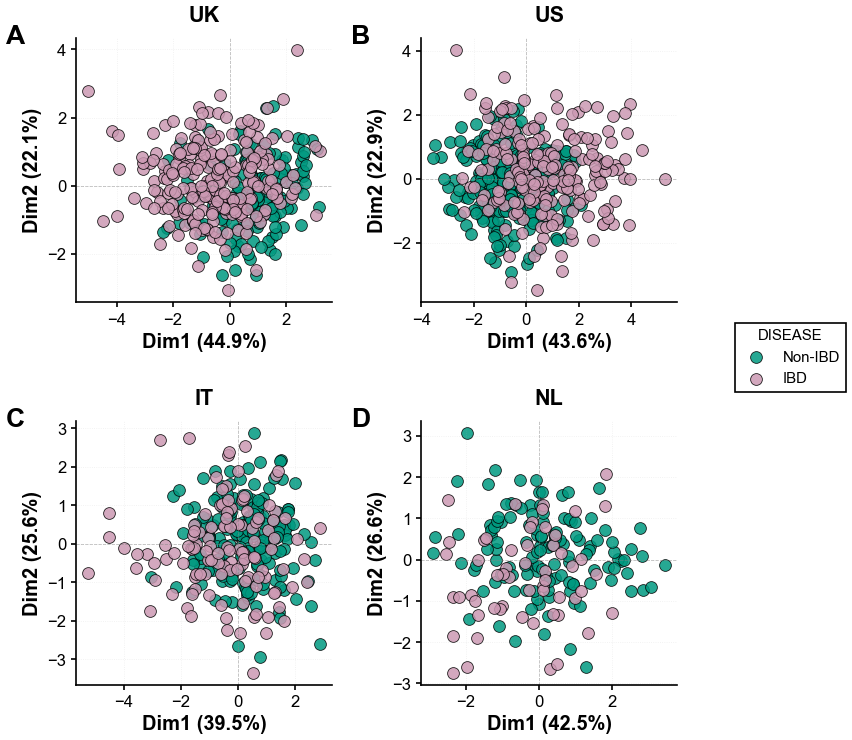

In [ ]:
# Primary cohort-specific Aitchison ordination: binary IBD endpoint
fig = plot_cohort_ordination_grid(
    binary_geometry.clr_ordination,
    cluster_col="DISEASE",
    cluster_order=DISEASE_ORDER_BINARY,
    colors=DISEASE_COLORS,
    cohort_order=COHORT_ORDER,
    legend_title="DISEASE",
)
_, _ = save_figure_aga_compliant(
    fig=fig,
    filename="figure 1",
    format="tiff",
    dpi=500,
    path=FIGURE_DIR,
)


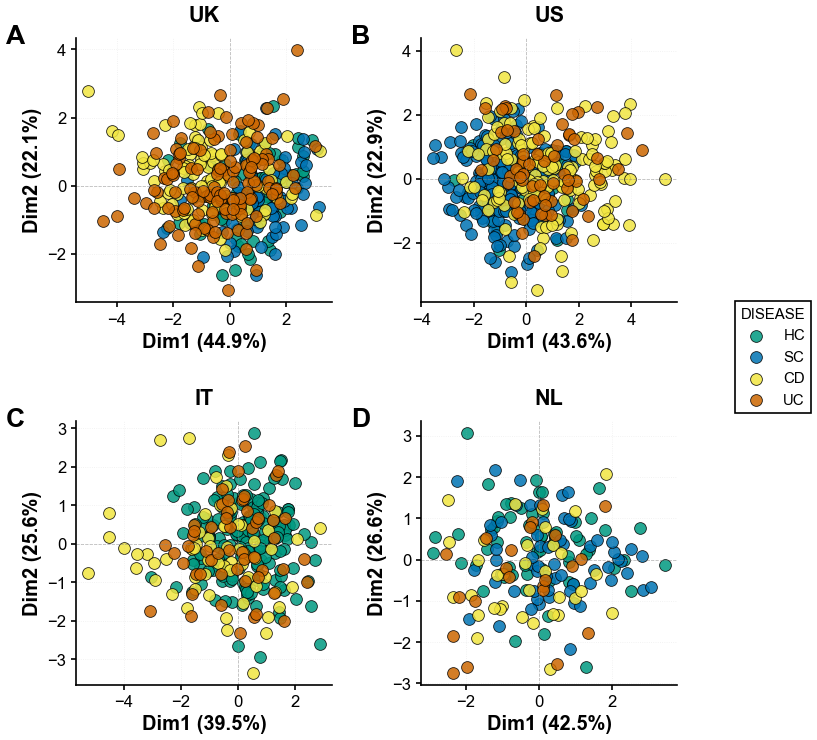

In [ ]:
# Secondary cohort-specific Aitchison ordination: multiclass endpoint
fig = plot_cohort_ordination_grid(
    multiclass_geometry.clr_ordination,
    cluster_col="DISEASE",
    cluster_order=DISEASE_ORDER_MULTI,
    colors=DISEASE_COLORS,
    cohort_order=COHORT_ORDER,
    legend_title="DISEASE",
)
_, _ = save_figure_aga_compliant(
    fig=fig,
    filename="figure S1",
    format="tiff",
    dpi=500,
    path=FIGURE_DIR,
)


## Is the Aitchison separation larger than expected after adjustment?

Ordination shows the geometry, but it does not test a disease effect. Partial PERMANOVA estimates the variation attributable to disease after age, sex, and cohort adjustment. Freedman–Lane residual permutations are restricted within cohort. The companion centroid-based PERMDISP test uses the same cohort restriction to check whether unequal within-group spread contributes to the result.


In [ ]:
global_inference = pd.DataFrame(
    [
        run_global_similarity_inference(
            binary_similarity,
            coda_cols,
            endpoint="Binary IBD vs non-IBD (primary)",
            term="DISEASE",
            covariates=PERMANOVA_COVARIATES,
            blocks="Cohort",
            n_permutations=N_PERMUTATIONS,
            random_state=SEED,
        ),
        run_global_similarity_inference(
            multiclass_similarity,
            coda_cols,
            endpoint="Multiclass HC/SC/CD/UC (secondary)",
            term="DISEASE",
            covariates=PERMANOVA_COVARIATES,
            blocks="Cohort",
            n_permutations=N_PERMUTATIONS,
            random_state=SEED,
        ),
    ]
)
display(global_inference.round(4))

binary_result = global_inference.iloc[0]
dispersion_description = (
    "PERMDISP was also significant, so both group location and dispersion "
    "contribute to the apparent separation."
    if binary_result["PERMDISP p"] < 0.05
    else "PERMDISP was not significant, providing no evidence that unequal "
    "dispersion explains the separation."
)
display(
    Markdown(
        "For the primary binary endpoint, disease explained "
        f"{100 * binary_result['Disease partial R2']:.2f}% of adjusted global "
        f"glycome variation (pseudo-F = {binary_result['PERMANOVA pseudo-F']:.2f}, "
        f"p = {binary_result['PERMANOVA p']:.3f}). {dispersion_description}"
    )
)


,Endpoint,PERMANOVA pseudo-F,Disease partial R2,PERMANOVA df,PERMANOVA p,PERMDISP F,PERMDISP df,PERMDISP p,Permutations,p-value resolution
0,Binary IBD vs non-IBD (primary),117.2120,0.0793,"1, 1360",0.001,54.0010,"1, 1365",0.001,999,0.001
1,Multiclass HC/SC/CD/UC (secondary),47.3187,0.0946,"3, 1358",0.001,19.1127,"3, 1363",0.001,999,0.001


For the primary binary endpoint, disease explained 7.93% of adjusted global glycome variation (pseudo-F = 117.21, p = 0.001). PERMDISP was also significant, so both group location and dispersion contribute to the apparent separation.

### How should we read this result?

We interpret partial R² as the magnitude of global disease separation and the permutation p-value as its statistical evidence. A significant PERMDISP result means that dispersion also contributes, so the ordination cannot be described as a pure shift in group location. These results concern relative glycan composition; they do not establish absolute changes in glycan amount.
